# MaVi-Volume: Model Inference and Evaluation

Load and evaluate the trained ResNet-50 volume prediction model.

## 1. Import Libraries

Import all required libraries for data processing, visualization, deep learning, and model evaluation.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

## 2. Set Random Seeds for Reproducibility

Ensure consistent results across multiple runs by setting seeds for all random number generators.

In [2]:
# Reproducibility
SEED = 3
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

## 3. Load Data from Excel

Read experimental data containing:
- **Number of droplets** per tube
- **Initial tube weights** (before adding liquid)
- **Final tube weights** (after adding liquid)

Mass is calculated as: `m = Final Weight - Initial Weight`
Volume is calculated as: `V = m / p` (where `p` is density in g/mL)

In [3]:
data_dir = r"C:\Users\lengo\Timme Lab\Code\liquid-measure\VolPicturesRound1"

xls_path = os.path.join(data_dir, "HFB Volume Image Gathering.xlsx")

drops_df = pd.read_excel(xls_path, sheet_name="# of Droplets", header=None)
pre_df   = pd.read_excel(xls_path, sheet_name="Initial Tube Weights", header=None)
post_df  = pd.read_excel(xls_path, sheet_name="Final Tube Weights", header=None)

# Liquid density p in g/mL (adjust if needed for your liquid)
p = 1.0

## 4. Load and Preprocess Images

Process all tube images from 10 runs × 20 tubes = 200 images:
- Convert to **grayscale** (single channel)
- Resize to **320×160 pixels**
- Normalize pixel values to **[0, 1]** range
- Extract volume labels from mass using `V = m / p`

In [4]:
wIm, hIm = 320, 160
nRuns, nTubes = 10, 20

images = []
volumes = []
drops = []
labels = []

for run in range(1, nRuns + 1):
    for tube in range(1, nTubes + 1):
        try:
            img_path = os.path.join(
                data_dir,
                f"Attempt{run}",
                f"Run{run}Rig1Tube{tube}final.bmp"
            )
            
            img = Image.open(img_path).convert("L")
            img = img.resize((wIm, hIm))
            img = np.array(img, dtype=np.float32) / 255.0
            
            mass = post_df.iloc[run, tube] - pre_df.iloc[run, tube]
            vol = mass / p
            nd  = drops_df.iloc[run, tube]

            images.append(img)
            volumes.append(vol)
            drops.append(nd)
            labels.append([run, tube])

        except Exception as e:
            print(f"Run {run} Tube {tube} failed:", e)


print(f"\n✓ Loaded {len(images)} images successfully");
print(f"  Image shape: {wIm}x{hIm}");
print(f"  Volume range: [{min(volumes):.3f}, {max(volumes):.3f}]")

Run 4 Tube 1 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt4\\Run4Rig1Tube1final.bmp'
Run 4 Tube 8 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt4\\Run4Rig1Tube8final.bmp'
Run 4 Tube 15 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt4\\Run4Rig1Tube15final.bmp'
Run 5 Tube 12 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt5\\Run5Rig1Tube12final.bmp'
Run 5 Tube 13 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt5\\Run5Rig1Tube13final.bmp'
Run 5 Tube 14 failed: [Errno 2] No such file or directory: 'C:\\Users\\lengo\\Timme Lab\\Code\\liquid-measure\\VolPicturesRound1\\Attempt5\\Run5Rig1Tube14final.bmp'

✓ Loaded 194 

## 5. Convert to NumPy Arrays

Prepare data for model input by converting lists to efficient NumPy arrays.

In [5]:
X = np.stack(images)
y = np.array(volumes, dtype=np.float32)

## 6. Split Data into Training and Test Sets

Split data using **80/20 ratio**:
- **Training set**: Used to train the model
- **Test set**: Used to evaluate final performance (held out during training)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Training set: 155 samples
Test set: 39 samples (20.1%)


## 7. Define Data Augmentation Transforms

**Training transforms** (increase model robustness):
- Random rotation: ±15 degrees
- Random translation: ±10 pixels
- Convert to tensor

**Test transforms** (no augmentation for consistent evaluation):
- Only convert to tensor

In [7]:
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomAffine(
        degrees=15,
        translate=(10/320, 10/160)
    ),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

## 8. Create Custom PyTorch Dataset

Custom `Dataset` class that:
- Stores images and labels
- Applies transformations on-the-fly during training
- Returns (image, volume) pairs for the DataLoader

In [8]:
class VolumeDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        img = (img * 255).astype(np.uint8)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img).unsqueeze(0)

        return img, torch.tensor(self.y[idx])

## 9. Create DataLoaders

Configure data loading for efficient batch processing:
- **Batch size**: 10 samples per batch
- **Training**: Shuffled for better generalization
- **Test**: Sequential for consistent evaluation

In [9]:
train_ds = VolumeDataset(X_train, y_train, train_tf)
test_ds  = VolumeDataset(X_test, y_test, test_tf)

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=10, shuffle=False)

## 10. Load Trained Model and Evaluate

**Load a pre-trained ResNet-50 model** and evaluate its performance on the test set:
- Recreate the model architecture (ResNet-50 with grayscale input)
- Load checkpoint containing model weights and training history
- Set model to evaluation mode
- Generate predictions on test set
- Calculate **RMSE** (Root Mean Squared Error) for performance assessment
- Visualize predictions vs ground truth with R² and p-values

In [10]:
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import linregress



In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [12]:
# To load a saved model:

# 1. Recreate the model architecture
loaded_model = models.resnet50(weights=False)
loaded_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
loaded_model.fc = nn.Sequential(
    nn.Linear(2048, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

# 2. Load the saved checkpoint
checkpoint = torch.load(
    'models/volume_predictor_resnet50_2026-05-01_13-17-08.pth',
    map_location=device,
    weights_only=False
 )
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.to(device)
loaded_model.eval()

# Make downstream cells use the loaded model automatically
model = loaded_model

# 3. Access training history if needed
training_history = checkpoint['training_history']
final_rmse = f"{checkpoint['rmse']:.4f}"

print(f"✓ Model loaded successfully!")
print(f"  Trained for {checkpoint['epoch']} epochs")
print(f"  Test RMSE: {final_rmse}")


c:\Users\lengo\Timme Lab\Code\liquid-measure\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model loaded successfully!
  Trained for 25 epochs
  Test RMSE: 0.0557


In [13]:
model.eval()

def predict(loader, model_to_use):
    preds = []
    targets = []
    with torch.no_grad():
        for x, yb in loader:
            x = x.to(device)
            p = model_to_use(x).cpu().numpy().squeeze()
            preds.extend(p)
            targets.extend(yb.numpy())
    return np.array(preds), np.array(targets)

y_pred_test, y_true_test = predict(test_loader, model)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))

print(f"\n{'='*40}")

print(f"Test Set Performance")

print(f"{'='*40}")
print(f"RMSE: {rmse:.4f}")
print(f"Number of test samples: {len(y_true_test)}")


Test Set Performance
RMSE: 0.0557
Number of test samples: 39


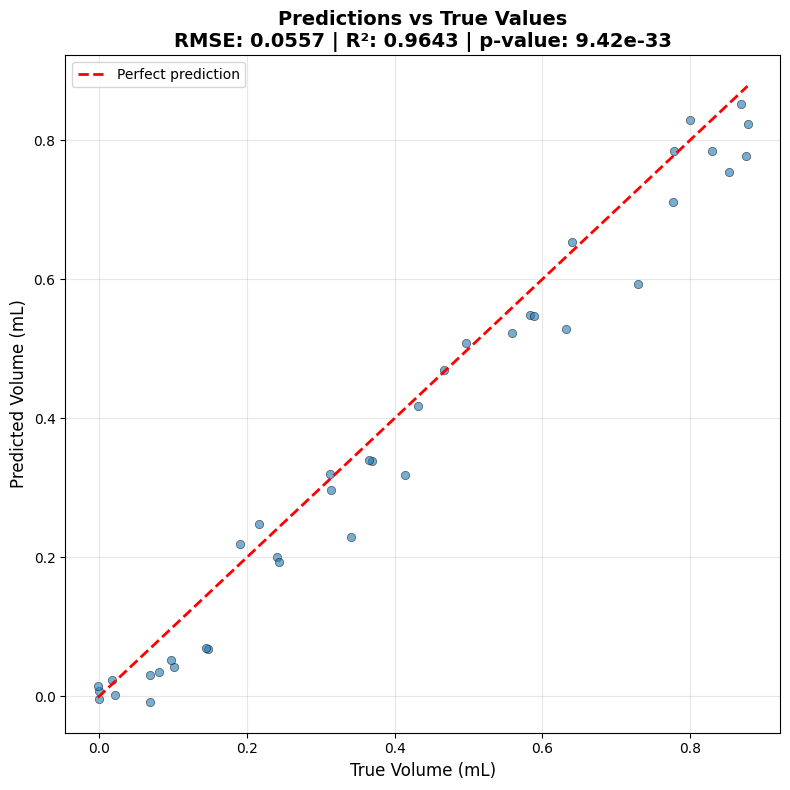

In [14]:
from scipy.stats import linregress

r2 = 1 - np.sum((y_true_test - y_pred_test) ** 2) / np.sum((y_true_test - np.mean(y_true_test)) ** 2)
fit = linregress(y_true_test, y_pred_test)
p_value = fit.pvalue

plt.figure(figsize=(8, 8))
plt.scatter(y_true_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], 
         [y_true_test.min(), y_true_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel("True Volume (mL)", fontsize=12)
plt.ylabel("Predicted Volume (mL)", fontsize=12)
plt.title(
    f"Predictions vs True Values\nRMSE: {rmse:.4f} | R²: {r2:.4f} | p-value: {p_value:.2e}",
    fontsize=14, fontweight='bold'
 )
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path

results_dir = Path("testing results")
results_dir.mkdir(exist_ok=True)

results_df = pd.DataFrame({
    'true_value_mL': y_true_test,
    'predicted_value_mL': y_pred_test,
    'error_mL': np.abs(y_true_test - y_pred_test)
})

excel_path = results_dir / 'test_predictions.xlsx'
with pd.ExcelWriter(excel_path) as writer:
    results_df.to_excel(writer, sheet_name='results', index=False)

print(f'Excel file saved to: {excel_path}')

Excel file saved to: testing results\test_predictions.xlsx
